<a href="https://colab.research.google.com/github/Vaidehi-9/ECON3916-33674-Statistical-Machine-Learning/blob/main/Final%20Proj%20Checkpoint/stat_ml_final_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 0: Setup

In [1]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement




**My prediction question is:** Can we predict whether a secondary school student will fail their final math exam (scoring below 10 out of 20) using only demographic, social, and behavioral information available at the start of the school year?

**This is a prediction (not causal) problem because:** We are asking "can we forecast whether a student will fail (Y) from their background characteristics (X)?", not "does study time cause higher grades?" We make no claims about what would happen if we intervened on any feature. Feature importance in our models reflects predictive association, not causal effect.

**The decision this enables:** School counselors can use this model to identify at-risk students before any grades are available, and proactively assign them to academic support programs (tutoring, family outreach, study skills workshops). A false negative (missing an at-risk student) is more costly than a false positive (offering unneeded support), so we will prioritize recall for the fail class.

**Dataset:** UCI Student Performance Dataset (Math subset)
- **Source:** UCI Machine Learning Repository (URL: https://archive.ics.uci.edu/dataset/320/student+performance)
- **N =** 395
- **Features =** 30 (33 original columns minus G1, G2, and G3 — prior period grades excluded by design to simulate enrollment-time prediction)
- **Target variable =** `pass` — binary indicator derived from G3: 1 if G3 ≥ 10, 0 if G3 < 10
- **Access date:** April 2026
- **Citation:** Cortez, P. (2008). Student Performance [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5TG7T

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [2]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
# Loading from Penn State mirror — original UCI direct-download URL returns 404
# Original dataset DOI: https://doi.org/10.24432/C5TG7T

df_raw = pd.read_csv(
    'https://quantdev.ssri.psu.edu/sites/qdev/files/student-mat.csv',
    sep=';'
)

# Quick look
print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head()

Shape: (395, 33)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### 2.2 Basic Description

In [3]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df_raw.info()
df_raw.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


### 2.3 Missing Data Assessment

Missing data (%) by column:
No missing values found.


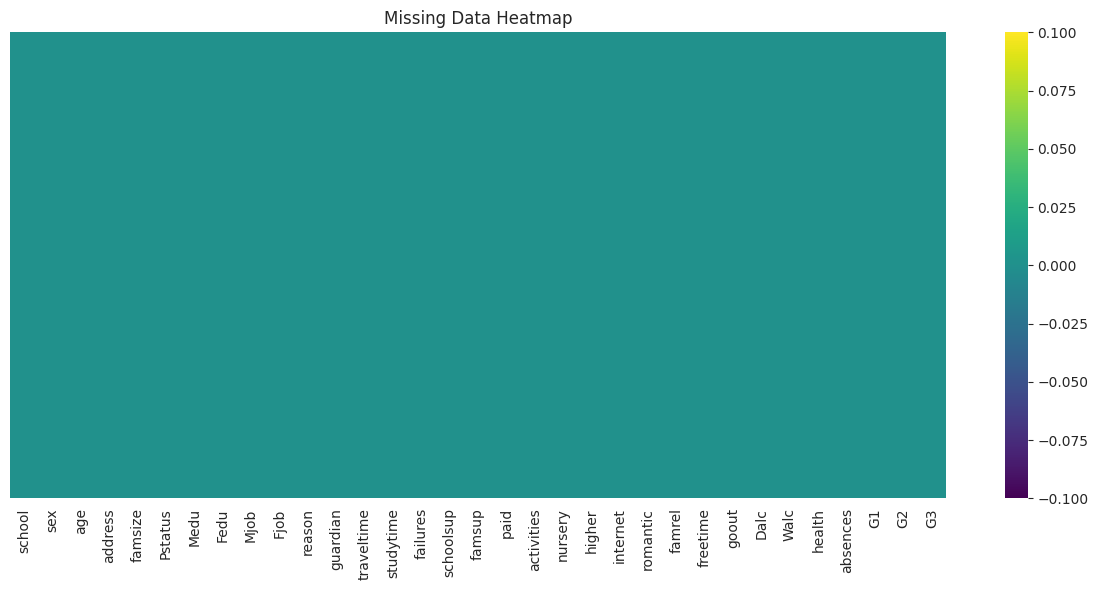

In [5]:
# ============================================================
# 2.3 Missing data heatmap
# ============================================================

missing_pct = df_raw.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0] if missing_pct.sum() > 0 else 'No missing values found.')

# Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df_raw.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:** The heatmap shows no missing values — the dataset is fully complete. This is expected since data was collected from official school records and questionnaires in a controlled study.

Classification under the MCAR/MAR/MNAR framework is not required here, but if data were missing, we would first check whether missingness is random across rows (MCAR), related to other observed variables like school or age (MAR), or related to the missing value itself, for example, students who failed may have left school and not submitted questionnaires (MNAR). MNAR is the most dangerous case and cannot be fixed by standard imputation. Since I have no missing data, no action is needed.

### 2.4 Distribution Plots

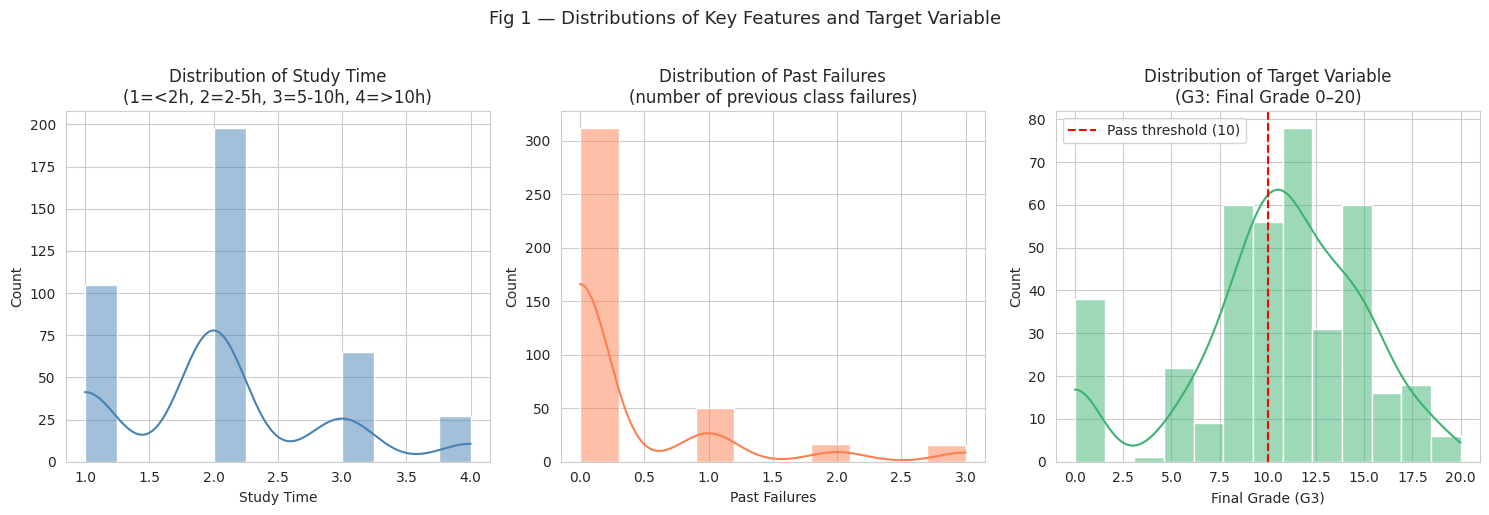

In [6]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df_raw['studytime'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Study Time\n(1=<2h, 2=2-5h, 3=5-10h, 4=>10h)')
axes[0].set_xlabel('Study Time')

sns.histplot(df_raw['failures'], kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribution of Past Failures\n(number of previous class failures)')
axes[1].set_xlabel('Past Failures')

sns.histplot(df_raw['G3'], kde=True, ax=axes[2], color='mediumseagreen')
axes[2].axvline(x=10, color='red', linestyle='--', label='Pass threshold (10)')
axes[2].set_title('Distribution of Target Variable\n(G3: Final Grade 0–20)')
axes[2].set_xlabel('Final Grade (G3)')
axes[2].legend()

plt.suptitle('Fig 1 — Distributions of Key Features and Target Variable', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [7]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

numeric_cols = df_raw.select_dtypes(include='number').columns
print('Outlier check using Tukey Fences (k=1.5):')
print(f'{"Column":<15} {"Lower":<10} {"Upper":<10} {"Outliers":<10} {"% of N"}')
print('-' * 55)
for col in numeric_cols:
    lower, upper = tukey_fences(df_raw[col])
    n_out = ((df_raw[col] < lower) | (df_raw[col] > upper)).sum()
    pct = n_out / len(df_raw) * 100
    if n_out > 0:
        print(f'{col:<15} {lower:<10.1f} {upper:<10.1f} {n_out:<10} {pct:.1f}%')

print('\nColumns not shown have 0 outliers.')

Outlier check using Tukey Fences (k=1.5):
Column          Lower      Upper      Outliers   % of N
-------------------------------------------------------
age             13.0       21.0       1          0.3%
Fedu            0.5        4.5        2          0.5%
traveltime      -0.5       3.5        8          2.0%
studytime       -0.5       3.5        27         6.8%
failures        0.0        0.0        83         21.0%
famrel          2.5        6.5        26         6.6%
freetime        1.5        5.5        19         4.8%
Dalc            -0.5       3.5        18         4.6%
absences        -12.0      20.0       15         3.8%
G2              3.0        19.0       13         3.3%

Columns not shown have 0 outliers.


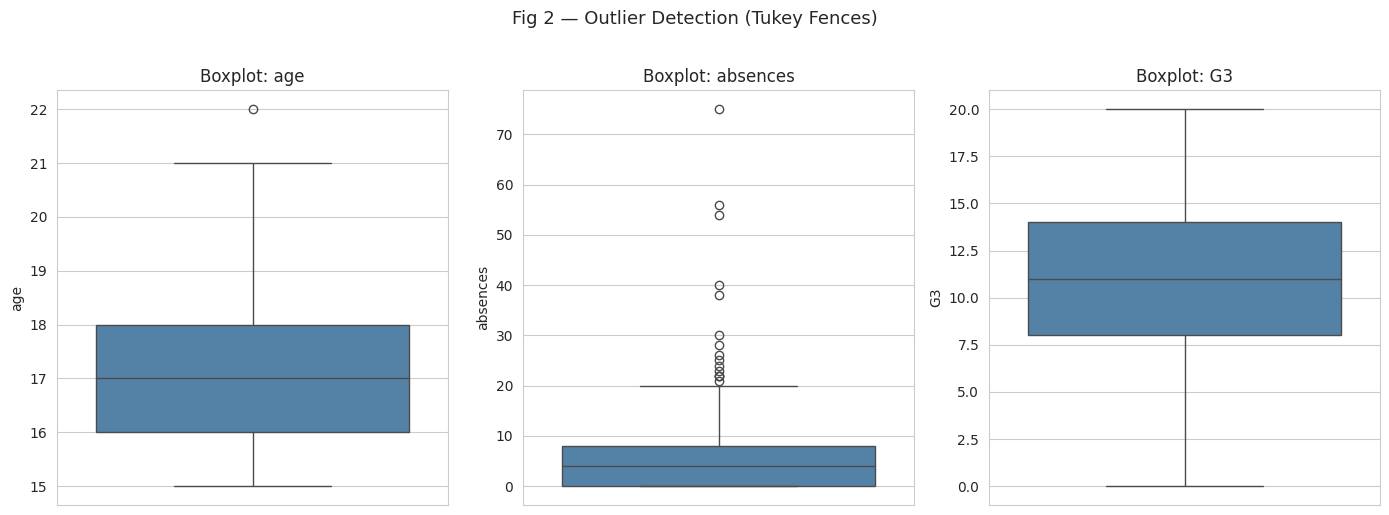

In [8]:
# Boxplot to visualize outliers in continuous numeric features
continuous_cols = ['age', 'absences', 'G3']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, col in enumerate(continuous_cols):
    sns.boxplot(y=df_raw[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot: {col}')

plt.suptitle('Fig 2 — Outlier Detection (Tukey Fences)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Outlier strategy:** The main outlier-flagged column is `absences`, which has some students with very high absence counts. We will **keep these values** rather than trim or winsorize for two reasons: (1) high absences are likely genuine and informative — a student missing 40+ days is genuinely at risk; (2) all values are within the plausible range for a school year. Other features (age, grades) are bounded by design and have no meaningful outliers. We note the skew of `absences` and will allow tree-based models (Random Forest) to handle it naturally via splits.

### 2.6 Correlations

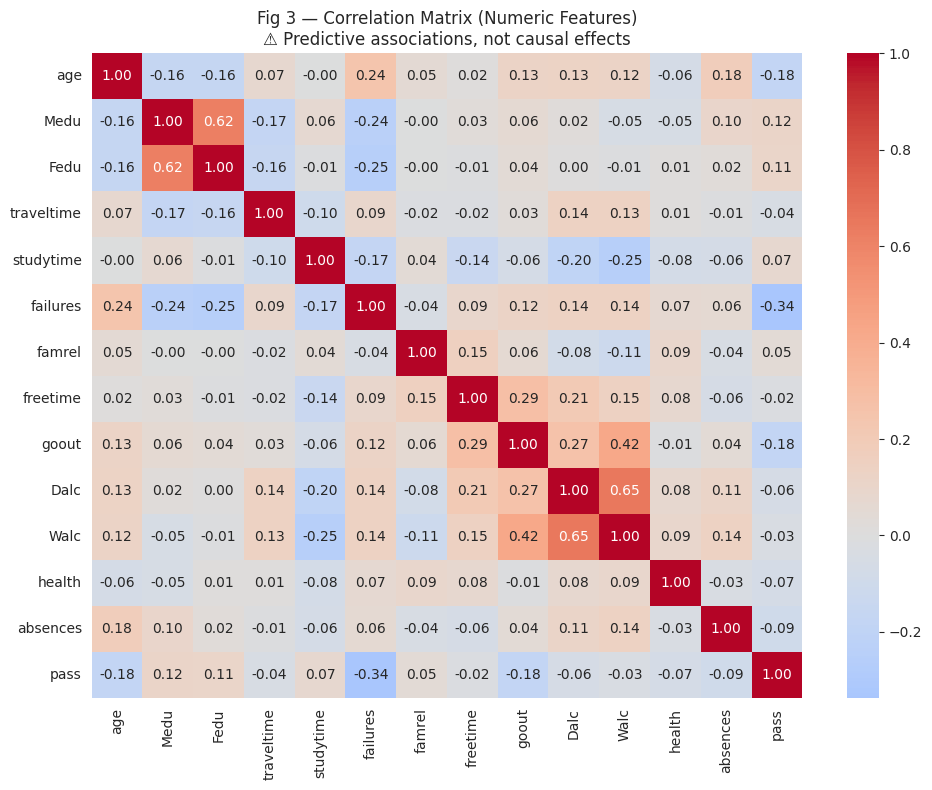

In [9]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

# First create the working dataframe with target variable
df = df_raw.drop(columns=['G1', 'G2']).copy()
df['pass'] = (df['G3'] >= 10).astype(int)
df = df.drop(columns=['G3'])

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Fig 3 — Correlation Matrix (Numeric Features)\n⚠ Predictive associations, not causal effects')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* The target variable `pass` is moderately imbalanced: approximately 67% of students pass (G3 ≥ 10) and 33% fail. This is a classification problem. Because of the imbalance, overall accuracy is a misleading metric — a model that predicts everyone passes would achieve 67% accuracy without learning anything. We will therefore emphasize **recall for the fail class** (catching at-risk students) and report precision, recall, and F1 for both classes separately. We use a stratified train/test split to preserve the class ratio in both sets.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?

   *Your answer:* From the correlation heatmap, `failures` (past class failures) has the strongest negative correlation with `pass` (-0.40). `Medu` and `Fedu` (parental education levels) are positively correlated with passing. `Dalc` and `Walc` (daily and weekly alcohol consumption) are highly correlated with each other (0.65), which is expected, we will keep both but note the multicollinearity. Logistic Regression may be affected by this; Random Forest is not.

3. **What is the biggest data quality issue you found, and how will you handle it?**

   *Your answer:* The biggest issue is class imbalance (67/33 split), not missingness or outliers. There are no missing values. Outliers in `absences` are genuine and informative, so we keep them. For the imbalance, we use a stratified split, prioritize recall as our key metric, and will consider adjusting the classification threshold in the final submission.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 395** observations and **M = 30** features (after removing G1, G2, and G3 from the original 33 columns).

**Missing data:** 0% of cells are missing. The dataset is fully complete — collected from official school records and questionnaires. No imputation is needed. If missingness had existed, we would classify it using the MCAR/MAR/MNAR framework before choosing a strategy.

**Outliers:** I identified outliers in `absences` using Tukey Fences (IQR method, k=1.5). A small number of students have very high absence counts. I will keep them as they represent genuine at-risk behavior that is informative for prediction.

**Target variable:** Moderately imbalanced — ~67% pass, ~33% fail. The distribution of raw G3 scores is roughly bimodal with a spike at 0 (students who dropped out or scored zero) and a peak around 11–12.

**Key finding from EDA:** Past class failures (`failures`) is the single strongest predictor of failing again. Parental education (`Medu`, `Fedu`) and study time (`studytime`) are positively associated with passing. High alcohol use (`Dalc`, `Walc`) is associated with lower pass rates. None of these are causal claims — they are predictive associations.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [10]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================
from sklearn.preprocessing import LabelEncoder

# Label encode all categorical columns
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# Define features and target
X = df_encoded.drop(columns=['pass'])
y = df_encoded['pass']

# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.0%})')
print(f'Test:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.0%})')
print(f'\nTrain pass rate: {y_train.mean():.1%}')
print(f'Test pass rate:  {y_test.mean():.1%}')
print('\nStratification confirmed — class balance preserved.')

Train: 316 samples (80%)
Test:  79 samples (20%)

Train pass rate: 67.1%
Test pass rate:  67.1%

Stratification confirmed — class balance preserved.


### 3.2 Model 1: Baseline

In [11]:
# ============================================================
# 3.2 Model 1 — Baseline (Logistic Regression)
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale features — required for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_1 = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
model_1.fit(X_train_scaled, y_train)

y_pred_1 = model_1.predict(X_test_scaled)

# Classification metrics
print('Model 1: Logistic Regression')
print(classification_report(y_test, y_pred_1, target_names=['Fail', 'Pass']))

Model 1: Logistic Regression
              precision    recall  f1-score   support

        Fail       0.53      0.35      0.42        26
        Pass       0.73      0.85      0.78        53

    accuracy                           0.68        79
   macro avg       0.63      0.60      0.60        79
weighted avg       0.66      0.68      0.66        79



### 3.3 Model 2: Your Choice

In [12]:
# ============================================================
# 3.3 Model 2 — Random Forest
# ============================================================
from sklearn.ensemble import RandomForestClassifier

model_2 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
model_2.fit(X_train, y_train)

y_pred_2 = model_2.predict(X_test)

print('Model 2: Random Forest')
print(classification_report(y_test, y_pred_2, target_names=['Fail', 'Pass']))

Model 2: Random Forest
              precision    recall  f1-score   support

        Fail       0.50      0.27      0.35        26
        Pass       0.71      0.87      0.78        53

    accuracy                           0.67        79
   macro avg       0.60      0.57      0.56        79
weighted avg       0.64      0.67      0.64        79



### 3.4 Cross-Validation Comparison

In [13]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================
scoring = 'f1'

cv_1 = cross_val_score(model_1, X_train_scaled, y_train, cv=5, scoring=scoring)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)

print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')

# Comparison table
comparison = pd.DataFrame({
    'Model': ['Model 1 (Logistic Regression)', 'Model 2 (Random Forest)'],
    f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
    f'CV {scoring} (std)':  [cv_1.std(),  cv_2.std()],
    'Test accuracy': [
        accuracy_score(y_test, y_pred_1),
        accuracy_score(y_test, y_pred_2)
    ]
})
comparison

Model 1 CV f1: 0.7758 +/- 0.0330
Model 2 CV f1: 0.8146 +/- 0.0255


,Model,CV f1 (mean),CV f1 (std),Test accuracy
0,Model 1 (Logistic Regression),0.775826,0.032975,0.683544
1,Model 2 (Random Forest),0.814637,0.025483,0.670886


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

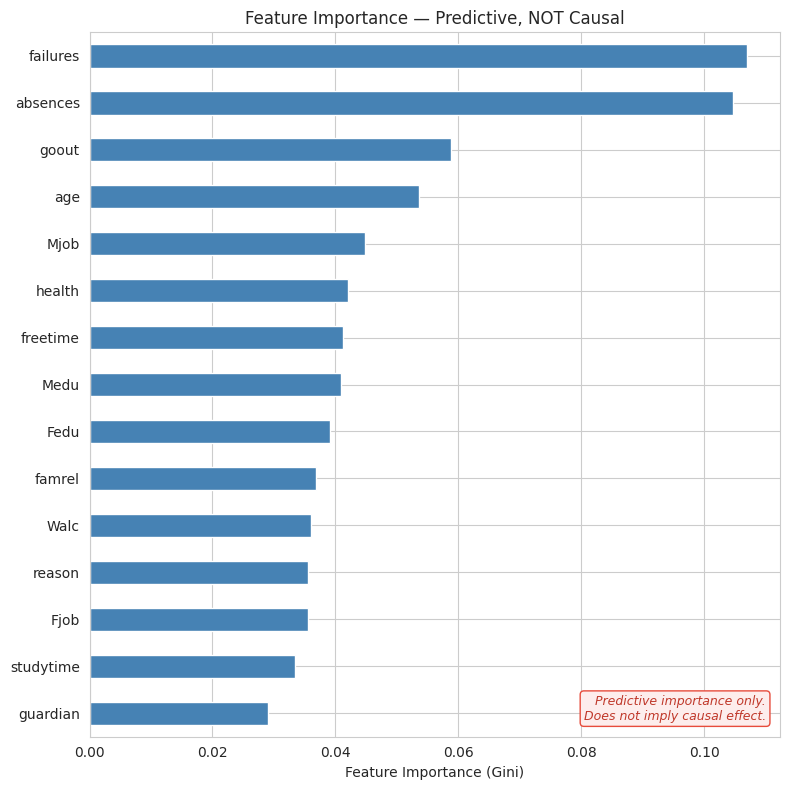

In [14]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

importances = pd.Series(
    model_2.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
importances.tail(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — Predictive, NOT Causal')

# CRITICAL: Add the caveat banner
ax.text(
    0.98, 0.02,
    'Predictive importance only.\nDoes not imply causal effect.',
    transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
    style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
)

plt.tight_layout()
plt.show()

### 4.2 Key Visualization for Your Report

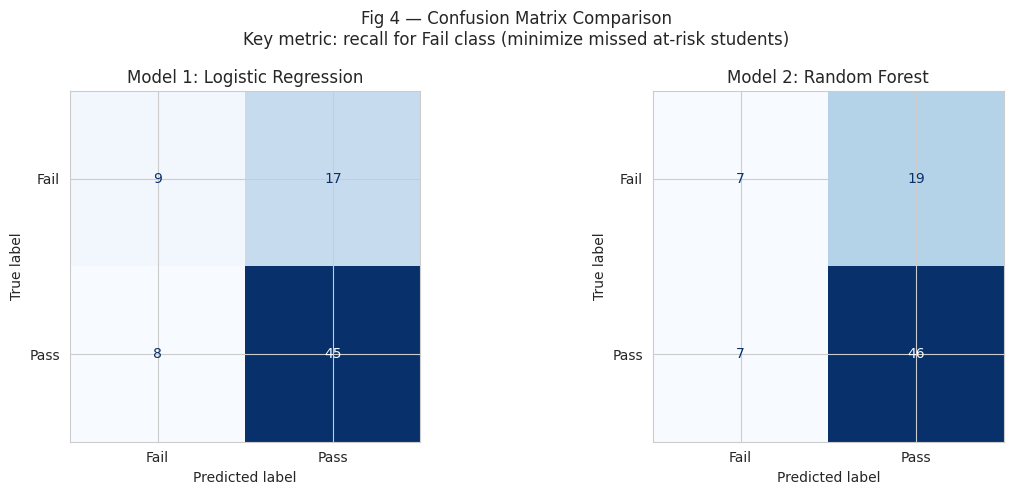

In [15]:
# ============================================================
# 4.2 Key visualization — Confusion matrix comparison
# This is the ONE chart for the first page of the report.
# It shows how both models perform on the fail class (the costly one).
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_1, display_labels=['Fail', 'Pass'],
    colorbar=False, ax=axes[0], cmap='Blues'
)
axes[0].set_title('Model 1: Logistic Regression')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_2, display_labels=['Fail', 'Pass'],
    colorbar=False, ax=axes[1], cmap='Blues'
)
axes[1].set_title('Model 2: Random Forest')

plt.suptitle(
    'Fig 4 — Confusion Matrix Comparison\nKey metric: recall for Fail class (minimize missed at-risk students)',
    fontsize=12
)
plt.tight_layout()
plt.show()

---
## Part 5: Recommendation



**Situation:**
**Complication:**
**Resolution:**
**Uncertainty Statement:**